In [11]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn kagglehub[pandas-datasets] ucimlrepo -q

In [12]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedGroupKFold
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    silhouette_score,
    confusion_matrix
)

from scipy.stats import binomtest

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

OUTPUT_DIR = "week2_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

np.random.seed(RANDOM_STATE)

print("Import thư viện thành công")

Import thư viện thành công


In [13]:
# =========================
# GLOBAL CONFIG
# =========================

RANDOM_STATE = 42
N_SPLITS = 5

MODEL_NAMES = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

OUTPUT_DIR = "week2_outputs"

OULAD_PATH = "./oulad/"

KEY = [
    "code_module",
    "code_presentation",
    "id_student"
]

FINAL_CUTOFF = 28

TIME_POINTS = [
    7,
    14,
    21,
    28
]

print("Global configuration loaded.")

Global configuration loaded.


In [14]:
def make_preprocessor(num_cols, cat_cols):
    transformers = []

    if len(num_cols) > 0:
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", num_pipe, num_cols))

    if len(cat_cols) > 0:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", cat_pipe, cat_cols))

    return ColumnTransformer(transformers)


def make_model(name, num_cols, cat_cols):
    prep = make_preprocessor(num_cols, cat_cols)

    if name == "Logistic Regression":
        estimator = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            C=1.0,
            random_state=RANDOM_STATE
        )

    elif name == "Decision Tree":
        estimator = DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )

    elif name == "Random Forest":
        estimator = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif name == "XGBoost":
        estimator = XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    else:
        raise ValueError(f"Không tồn tại model: {name}")

    return Pipeline([
        ("prep", prep),
        ("model", estimator)
    ])


def evaluate_probability(y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Error Rate": 1 - accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "Threshold": threshold
    }


def find_best_threshold(y_true, probability):
    thresholds = np.arange(0.20, 0.81, 0.01)

    scores = []
    for threshold in thresholds:
        pred = (probability >= threshold).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        scores.append(score)

    best_index = int(np.argmax(scores))
    return float(thresholds[best_index])


def get_splits(y, groups=None):
    if groups is None:
        cv = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE
        )
        return list(cv.split(np.zeros(len(y)), y))

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    return list(cv.split(np.zeros(len(y)), y, groups))


def linear_slope(times, values):
    df = pd.DataFrame({
        "time": pd.to_numeric(times, errors="coerce"),
        "value": pd.to_numeric(values, errors="coerce")
    })

    # Loại NaN và vô cùng
    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # Phải có ít nhất 2 điểm
    if len(df) < 2:
        return 0.0

    x = df["time"].to_numpy(dtype=float)
    y = df["value"].to_numpy(dtype=float)

    # Nếu toàn bộ thời điểm giống nhau thì không tính được slope
    if np.unique(x).size < 2:
        return 0.0

    # Nếu dữ liệu vẫn có giá trị không hữu hạn
    if not np.all(np.isfinite(x)):
        return 0.0

    if not np.all(np.isfinite(y)):
        return 0.0

    try:
        slope = np.polyfit(
            x,
            y,
            1
        )[0]

        if not np.isfinite(slope):
            return 0.0

        return float(slope)

    except (
        np.linalg.LinAlgError,
        ValueError,
        TypeError
    ):
        return 0.0

In [15]:
def choose_k(X, k_values=(2, 3, 4, 5), tolerance=0.01):
    X = (
        pd.DataFrame(X)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scores = {}

    for k in k_values:
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10
        )

        labels = model.fit_predict(X_scaled)

        sample_size = min(5000, len(X_scaled))

        scores[k] = silhouette_score(
            X_scaled,
            labels,
            sample_size=sample_size,
            random_state=RANDOM_STATE
        )

    max_score = max(scores.values())

    # Nếu nhiều k gần tương đương, chọn k nhỏ hơn để mô hình dễ diễn giải hơn.
    candidates = [
        k for k, score in scores.items()
        if score >= max_score - tolerance
    ]

    return min(candidates), scores


def fit_cluster_state_model(X_fit, y_fit, k, smoothing=10.0):
    X_fit = (
        pd.DataFrame(X_fit)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_fit)

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    global_risk = float(np.mean(y_fit))
    risk_map = {}

    for cluster in range(k):
        mask = labels == cluster
        n_cluster = int(mask.sum())
        risk_count = float(np.sum(y_fit[mask]))

        risk_map[cluster] = (
            risk_count + smoothing * global_risk
        ) / (
            n_cluster + smoothing
        )

    # Tạo 3 trạng thái tương đối: Thấp / Trung bình / Cao
    # dựa trên thứ hạng rủi ro của các cụm, không dựa vào nhãn cluster tùy ý.
    ordered_clusters = sorted(risk_map, key=risk_map.get)
    state_map = {}

    if len(ordered_clusters) == 1:
        state_map[ordered_clusters[0]] = 1
    else:
        for rank, cluster in enumerate(ordered_clusters):
            normalized_rank = rank / (len(ordered_clusters) - 1)
            state_map[cluster] = int(round(normalized_rank * 2))

    return {
        "scaler": scaler,
        "kmeans": kmeans,
        "risk_map": risk_map,
        "state_map": state_map
    }


def apply_cluster_state(model_pack, X):
    X = (
        pd.DataFrame(X)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    X_scaled = model_pack["scaler"].transform(X)
    clusters = model_pack["kmeans"].predict(X_scaled)

    risk = np.array([
        model_pack["risk_map"][cluster]
        for cluster in clusters
    ])

    state = np.array([
        model_pack["state_map"][cluster]
        for cluster in clusters
    ])

    distance = (
        model_pack["kmeans"]
        .transform(X_scaled)
        .min(axis=1)
    )

    return clusters, risk, state, distance


def make_dynamic_summary(risk_matrix, state_matrix, distance_matrix, time_values):
    result = pd.DataFrame()

    result["risk_current"] = risk_matrix[:, -1]
    result["risk_mean"] = risk_matrix.mean(axis=1)
    result["risk_max"] = risk_matrix.max(axis=1)
    result["risk_change"] = risk_matrix[:, -1] - risk_matrix[:, -2]

    result["risk_slope"] = [
        linear_slope(time_values, row)
        for row in risk_matrix
    ]

    result["n_state_changes"] = np.sum(
        state_matrix[:, 1:] != state_matrix[:, :-1],
        axis=1
    )

    result["distance_current"] = distance_matrix[:, -1]
    result["state_current"] = state_matrix[:, -1]

    state_name = {
        0: "Thấp",
        1: "Trung bình",
        2: "Cao"
    }

    result["state_name"] = result["state_current"].map(state_name)

    return result


DYNAMIC_FEATURES = [
    "risk_current",
    "risk_mean",
    "risk_max",
    "risk_change",
    "risk_slope",
    "n_state_changes",
    "distance_current"
]

In [16]:
def build_crossfit_dynamic_features(
    train_stage_frames,
    test_stage_frames,
    y_train,
    feature_map,
    time_values,
    groups=None
):
    stages = list(train_stage_frames.keys())
    splits = get_splits(y_train, groups)

    n_train = len(y_train)
    n_test = len(next(iter(test_stage_frames.values())))
    n_stage = len(stages)

    oof_risk = np.zeros((n_train, n_stage))
    oof_state = np.zeros((n_train, n_stage), dtype=int)
    oof_distance = np.zeros((n_train, n_stage))

    test_risk = np.zeros((n_test, n_stage))
    test_state = np.zeros((n_test, n_stage), dtype=int)
    test_distance = np.zeros((n_test, n_stage))

    diagnostics = {}

    for stage_index, stage in enumerate(stages):
        features = feature_map[stage]

        X_train_stage = (
            train_stage_frames[stage][features]
            .reset_index(drop=True)
        )

        X_test_stage = (
            test_stage_frames[stage][features]
            .reset_index(drop=True)
        )

        # k chỉ được chọn từ tập train, không dùng test.
        best_k, silhouette_scores = choose_k(X_train_stage)

        diagnostics[stage] = {
            "best_k": best_k,
            "silhouette": silhouette_scores
        }

        # Cross-fitting cho train để risk-rate của cụm không nhìn thấy nhãn của chính hàng đó.
        for train_idx, valid_idx in splits:
            cluster_model = fit_cluster_state_model(
                X_train_stage.iloc[train_idx],
                y_train[train_idx],
                best_k
            )

            _, risk, state, distance = apply_cluster_state(
                cluster_model,
                X_train_stage.iloc[valid_idx]
            )

            oof_risk[valid_idx, stage_index] = risk
            oof_state[valid_idx, stage_index] = state
            oof_distance[valid_idx, stage_index] = distance

        # Mô hình cuối cùng của từng thời điểm: train toàn bộ train -> áp dụng test.
        full_cluster_model = fit_cluster_state_model(
            X_train_stage,
            y_train,
            best_k
        )

        _, risk, state, distance = apply_cluster_state(
            full_cluster_model,
            X_test_stage
        )

        test_risk[:, stage_index] = risk
        test_state[:, stage_index] = state
        test_distance[:, stage_index] = distance

        diagnostics[stage]["risk_map"] = full_cluster_model["risk_map"]
        diagnostics[stage]["state_map"] = full_cluster_model["state_map"]

    train_dynamic = make_dynamic_summary(
        oof_risk,
        oof_state,
        oof_distance,
        time_values
    )

    test_dynamic = make_dynamic_summary(
        test_risk,
        test_state,
        test_distance,
        time_values
    )

    return train_dynamic, test_dynamic, diagnostics


def crossfit_base_models(
    X_train,
    y_train,
    X_test,
    num_cols,
    cat_cols,
    groups=None
):
    splits = get_splits(y_train, groups)

    oof_predictions = {}
    test_predictions = {}
    fitted_models = {}

    for name in MODEL_NAMES:
        oof = np.zeros(len(X_train))

        for train_idx, valid_idx in splits:
            model = make_model(name, num_cols, cat_cols)

            model.fit(
                X_train.iloc[train_idx],
                y_train[train_idx]
            )

            oof[valid_idx] = (
                model.predict_proba(
                    X_train.iloc[valid_idx]
                )[:, 1]
            )

        final_model = make_model(name, num_cols, cat_cols)
        final_model.fit(X_train, y_train)

        test_probability = final_model.predict_proba(X_test)[:, 1]

        oof_predictions[name] = oof
        test_predictions[name] = test_probability
        fitted_models[name] = final_model

    return oof_predictions, test_predictions, fitted_models


def crossfit_meta_model(meta_train, y_train, meta_test, groups=None):
    splits = get_splits(y_train, groups)
    oof = np.zeros(len(meta_train))

    for train_idx, valid_idx in splits:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ])

        model.fit(
            meta_train[train_idx],
            y_train[train_idx]
        )

        oof[valid_idx] = model.predict_proba(
            meta_train[valid_idx]
        )[:, 1]

    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    final_model.fit(meta_train, y_train)
    test_probability = final_model.predict_proba(meta_test)[:, 1]

    return oof, test_probability, final_model


def evaluate_model_set(y_train, y_test, oof_prob, test_prob):
    rows = []

    for name in MODEL_NAMES:
        threshold = find_best_threshold(y_train, oof_prob[name])

        metrics = evaluate_probability(
            y_test,
            test_prob[name],
            threshold
        )

        metrics["Model"] = name
        rows.append(metrics)

    return pd.DataFrame(rows)

# PHẦN A — OULAD

## 4. Đặc trưng OULAD

OULAD là bộ dữ liệu đa bảng nên không có một số lượng cột đầu vào cố định cho toàn bộ bài toán.

Trong thực nghiệm này sử dụng **18 đặc trưng ngữ nghĩa**:

- 8 đặc trưng nền: hồ sơ và lịch sử học tập.
- 10 đặc trưng hành vi/học tập được xây dựng từ VLE và assessment.

Phân cụm động chỉ dùng **10 đặc trưng hành vi**, tránh đưa biến nhân khẩu học vào K-Means.

In [17]:
OULAD_PATH = "./oulad/"

courses = pd.read_csv(os.path.join(OULAD_PATH, "courses.csv"))
assessments = pd.read_csv(os.path.join(OULAD_PATH, "assessments.csv"))
studentAssessment = pd.read_csv(os.path.join(OULAD_PATH, "studentAssessment.csv"))
studentInfo = pd.read_csv(os.path.join(OULAD_PATH, "studentInfo.csv"))
studentRegistration = pd.read_csv(os.path.join(OULAD_PATH, "studentRegistration.csv"))
studentVle = pd.read_csv(os.path.join(OULAD_PATH, "studentVle.csv"))
vle = pd.read_csv(os.path.join(OULAD_PATH, "vle.csv"))

print("courses:", courses.shape)
print("assessments:", assessments.shape)
print("studentAssessment:", studentAssessment.shape)
print("studentInfo:", studentInfo.shape)
print("studentRegistration:", studentRegistration.shape)
print("studentVle:", studentVle.shape)
print("vle:", vle.shape)

courses: (22, 3)
assessments: (206, 6)
studentAssessment: (173912, 5)
studentInfo: (32593, 12)
studentRegistration: (32593, 5)
studentVle: (10655280, 6)
vle: (6364, 6)


In [18]:
KEY = ["code_module", "code_presentation", "id_student"]
FINAL_CUTOFF = 28
TIME_POINTS = [7, 14, 21, 28]

studentInfo["student_key"] = (
    studentInfo["code_module"].astype(str)
    + "_"
    + studentInfo["code_presentation"].astype(str)
    + "_"
    + studentInfo["id_student"].astype(str)
)

studentRegistration["student_key"] = (
    studentRegistration["code_module"].astype(str)
    + "_"
    + studentRegistration["code_presentation"].astype(str)
    + "_"
    + studentRegistration["id_student"].astype(str)
)

oulad_base = studentInfo.merge(
    studentRegistration[
        KEY + ["date_registration", "date_unregistration"]
    ],
    on=KEY,
    how="left"
)

oulad_base = oulad_base.merge(
    courses,
    on=["code_module", "code_presentation"],
    how="left"
)

oulad_base["target"] = (
    oulad_base["final_result"]
    .isin(["Fail", "Withdrawn"])
    .astype(int)
)

# Cohort đánh giá tại ngày 28:
# chỉ dự báo những SV chưa rút học trước thời điểm cảnh báo.
oulad_base = oulad_base[
    oulad_base["date_unregistration"].isna()
    | (oulad_base["date_unregistration"] > FINAL_CUTOFF)
].copy()

studentVle2 = studentVle.merge(
    vle[
        [
            "code_module",
            "code_presentation",
            "id_site",
            "activity_type"
        ]
    ],
    on=["code_module", "code_presentation", "id_site"],
    how="left"
)

studentAssessment2 = studentAssessment.merge(
    assessments[
        [
            "code_module",
            "code_presentation",
            "id_assessment",
            "assessment_type",
            "date",
            "weight"
        ]
    ],
    on="id_assessment",
    how="left",
    suffixes=("_submitted", "_assessment")
)

print("Cohort OULAD:", len(oulad_base))
print(oulad_base["target"].value_counts())

Cohort OULAD: 27538
target
0    15385
1    12153
Name: count, dtype: int64


In [19]:
def build_oulad_snapshot(cutoff):
    base = oulad_base.copy()

    # ---------- VLE ----------
    vle_cut = studentVle2[
        studentVle2["date"] <= cutoff
    ].copy()

    vle_agg = (
        vle_cut.groupby(KEY)
        .agg(
            total_clicks=("sum_click", "sum"),
            active_days=("date", "nunique"),
            activity_diversity=("activity_type", "nunique"),
            last_activity_day=("date", "max")
        )
        .reset_index()
    )

    recent_agg = (
        vle_cut[
            vle_cut["date"] >= cutoff - 6
        ]
        .groupby(KEY)["sum_click"]
        .sum()
        .reset_index(name="clicks_last_7d")
    )

    vle_agg = vle_agg.merge(
        recent_agg,
        on=KEY,
        how="left"
    )

    vle_agg["days_since_last_activity"] = (
        cutoff - vle_agg["last_activity_day"]
    )

    daily_click = (
        vle_cut
        .groupby(KEY + ["date"])["sum_click"]
        .sum()
        .reset_index()
    )

    click_trend_rows = []

    for key, group in daily_click.groupby(KEY):
        click_trend_rows.append({
            "code_module": key[0],
            "code_presentation": key[1],
            "id_student": key[2],
            "click_trend": linear_slope(
                group["date"],
                group["sum_click"]
            )
        })

    click_trend = pd.DataFrame(click_trend_rows)

    if not click_trend.empty:
        vle_agg = vle_agg.merge(
            click_trend,
            on=KEY,
            how="left"
        )
    else:
        vle_agg["click_trend"] = 0.0

    # ---------- Assessment ----------
    assess_cut = studentAssessment2[
        studentAssessment2["date_submitted"] <= cutoff
    ].copy()

    assess_agg = (
        assess_cut.groupby(KEY)
        .agg(
            avg_assessment_score=("score", "mean"),
            submissions_count=("id_assessment", "nunique"),
            completed_weight=("weight", "sum")
        )
        .reset_index()
    )

    score_trend_rows = []

    for key, group in assess_cut.groupby(KEY):
        score_trend_rows.append({
            "code_module": key[0],
            "code_presentation": key[1],
            "id_student": key[2],
            "score_trend": linear_slope(
                group["date_submitted"],
                group["score"]
            )
        })

    score_trend = pd.DataFrame(score_trend_rows)

    if not score_trend.empty:
        assess_agg = assess_agg.merge(
            score_trend,
            on=KEY,
            how="left"
        )
    else:
        assess_agg["score_trend"] = 0.0

    # ---------- Merge ----------
    snapshot = base.merge(
        vle_agg,
        on=KEY,
        how="left"
    )

    snapshot = snapshot.merge(
        assess_agg,
        on=KEY,
        how="left"
    )

    fill_zero = [
        "total_clicks",
        "clicks_last_7d",
        "active_days",
        "activity_diversity",
        "submissions_count",
        "completed_weight",
        "click_trend",
        "score_trend"
    ]

    for col in fill_zero:
        snapshot[col] = snapshot[col].fillna(0)

    snapshot["days_since_last_activity"] = (
        snapshot["days_since_last_activity"]
        .fillna(cutoff)
    )

    return snapshot


oulad_snapshots = {
    time: build_oulad_snapshot(time)
    for time in TIME_POINTS
}

for time, frame in oulad_snapshots.items():
    print(f"Day {time}: {frame.shape}")

Day 7: (27538, 28)
Day 14: (27538, 28)
Day 21: (27538, 28)
Day 28: (27538, 28)


In [20]:
OULAD_NUM_FEATURES = [
    "num_of_prev_attempts",
    "studied_credits",
    "date_registration",
    "module_presentation_length",
    "total_clicks",
    "clicks_last_7d",
    "active_days",
    "activity_diversity",
    "days_since_last_activity",
    "avg_assessment_score",
    "submissions_count",
    "completed_weight",
    "click_trend",
    "score_trend"
]

OULAD_CAT_FEATURES = [
    "gender",
    "highest_education",
    "age_band",
    "imd_band"
]

OULAD_FEATURES = OULAD_NUM_FEATURES + OULAD_CAT_FEATURES

OULAD_CLUSTER_FEATURES = [
    "total_clicks",
    "clicks_last_7d",
    "active_days",
    "activity_diversity",
    "days_since_last_activity",
    "avg_assessment_score",
    "submissions_count",
    "completed_weight",
    "click_trend",
    "score_trend"
]

print("OULAD semantic features:", len(OULAD_FEATURES))
print("OULAD clustering features:", len(OULAD_CLUSTER_FEATURES))

OULAD semantic features: 18
OULAD clustering features: 10


In [21]:
final_df = oulad_snapshots[FINAL_CUTOFF].copy()

student_level = (
    final_df[["id_student", "target"]]
    .drop_duplicates("id_student")
)

train_students, test_students = train_test_split(
    student_level["id_student"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=student_level["target"]
)

train_ids = set(train_students)
test_ids = set(test_students)

train_final = final_df[
    final_df["id_student"].isin(train_ids)
].copy()

test_final = final_df[
    final_df["id_student"].isin(test_ids)
].copy()

# Cố định thứ tự khóa để mọi snapshot thẳng hàng.
train_keys = train_final["student_key"].tolist()
test_keys = test_final["student_key"].tolist()

train_stage_frames = {}
test_stage_frames = {}

for time in TIME_POINTS:
    snapshot = oulad_snapshots[time].set_index("student_key")

    train_stage_frames[time] = (
        snapshot.loc[train_keys]
        .reset_index()
    )

    test_stage_frames[time] = (
        snapshot.loc[test_keys]
        .reset_index()
    )

X_train_oulad = train_final[OULAD_FEATURES].reset_index(drop=True)
X_test_oulad = test_final[OULAD_FEATURES].reset_index(drop=True)

y_train_oulad = train_final["target"].to_numpy()
y_test_oulad = test_final["target"].to_numpy()

groups_train_oulad = train_final["id_student"].to_numpy()

print("Train:", X_train_oulad.shape)
print("Test:", X_test_oulad.shape)
print("Student overlap:", len(train_ids.intersection(test_ids)))

Train: (21960, 18)
Test: (5578, 18)
Student overlap: 0


In [22]:
oulad_cluster_feature_map = {
    time: OULAD_CLUSTER_FEATURES
    for time in TIME_POINTS
}

oulad_dynamic_train, oulad_dynamic_test, oulad_cluster_diagnostics = (
    build_crossfit_dynamic_features(
        train_stage_frames=train_stage_frames,
        test_stage_frames=test_stage_frames,
        y_train=y_train_oulad,
        feature_map=oulad_cluster_feature_map,
        time_values=TIME_POINTS,
        groups=groups_train_oulad
    )
)

for time in TIME_POINTS:
    info = oulad_cluster_diagnostics[time]

    print(f"Day {time}")
    print("  best k:", info["best_k"])
    print("  silhouette:", info["silhouette"])
    print("  risk map:", info["risk_map"])
    print()

print("Trạng thái cuối kỳ vọng trên TEST:")
print(oulad_dynamic_test["state_name"].value_counts())

Day 7
  best k: 3
  silhouette: {2: 0.31147584676141926, 3: 0.3336462626255858, 4: 0.32365774454287105, 5: 0.3352035272768323}
  risk map: {0: 0.30986553729039645, 1: 0.5138696503352131, 2: 0.6428211384907951}

Day 14
  best k: 5
  silhouette: {2: 0.2847747878686347, 3: 0.2832644645549002, 4: 0.29640006552181114, 5: 0.3526765589029078}
  risk map: {0: 0.6636573452949007, 1: 0.25908916236836177, 2: 0.43762912384646924, 3: 0.6041689900003717, 4: 0.3346574160756002}

Day 21
  best k: 4
  silhouette: {2: 0.2570942168194677, 3: 0.26818564194390226, 4: 0.29892755019500783, 5: 0.3082773305354446}
  risk map: {0: 0.716937152705725, 1: 0.251784920327582, 2: 0.4734630759811466, 3: 0.40302633291470313}

Day 28
  best k: 5
  silhouette: {2: 0.2602503065685421, 3: 0.2850754239811384, 4: 0.2946724697251384, 5: 0.307101824641211}
  risk map: {0: 0.6041689900003717, 1: 0.48767309034844003, 2: 0.43356368515535343, 3: 0.7512939625482189, 4: 0.26033254644451675}

Trạng thái cuối kỳ vọng trên TEST:
state_

In [23]:
oulad_oof, oulad_test_prob, oulad_models = crossfit_base_models(
    X_train=X_train_oulad,
    y_train=y_train_oulad,
    X_test=X_test_oulad,
    num_cols=OULAD_NUM_FEATURES,
    cat_cols=OULAD_CAT_FEATURES,
    groups=groups_train_oulad
)

oulad_baselines = evaluate_model_set(
    y_train_oulad,
    y_test_oulad,
    oulad_oof,
    oulad_test_prob
)

oulad_meta_train_base = np.column_stack([
    oulad_oof[name]
    for name in MODEL_NAMES
])

oulad_meta_test_base = np.column_stack([
    oulad_test_prob[name]
    for name in MODEL_NAMES
])

# Base stacking: chỉ 4 xác suất.
oulad_base_oof, oulad_base_test_prob, oulad_base_meta_model = (
    crossfit_meta_model(
        oulad_meta_train_base,
        y_train_oulad,
        oulad_meta_test_base,
        groups=groups_train_oulad
    )
)

oulad_base_threshold = find_best_threshold(
    y_train_oulad,
    oulad_base_oof
)

oulad_base_metrics = evaluate_probability(
    y_test_oulad,
    oulad_base_test_prob,
    oulad_base_threshold
)
oulad_base_metrics["Model"] = "Base Stacking"

# DRS-Stack: 4 xác suất + dynamic risk-state features.
oulad_meta_train_drs = np.column_stack([
    oulad_meta_train_base,
    oulad_dynamic_train[DYNAMIC_FEATURES].to_numpy()
])

oulad_meta_test_drs = np.column_stack([
    oulad_meta_test_base,
    oulad_dynamic_test[DYNAMIC_FEATURES].to_numpy()
])

oulad_drs_oof, oulad_drs_test_prob, oulad_drs_model = (
    crossfit_meta_model(
        oulad_meta_train_drs,
        y_train_oulad,
        oulad_meta_test_drs,
        groups=groups_train_oulad
    )
)

oulad_drs_threshold = find_best_threshold(
    y_train_oulad,
    oulad_drs_oof
)

oulad_drs_metrics = evaluate_probability(
    y_test_oulad,
    oulad_drs_test_prob,
    oulad_drs_threshold
)
oulad_drs_metrics["Model"] = "DRS-Stack"

oulad_results = pd.concat([
    oulad_baselines,
    pd.DataFrame([oulad_drs_metrics])
], ignore_index=True)

oulad_results = oulad_results[
    [
        "Model",
        "Accuracy",
        "Error Rate",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Threshold"
    ]
].sort_values("Error Rate").reset_index(drop=True)

oulad_results

,Model,Accuracy,Error Rate,Precision,Recall,F1,ROC-AUC,Threshold
0,Random Forest,0.673539,0.326461,0.601152,0.765593,0.673480,0.765079,0.41
1,DRS-Stack,0.671388,0.328612,0.592317,0.810844,0.684564,0.770873,0.37
2,XGBoost,0.669416,0.330584,0.588543,0.825112,0.687033,0.771867,0.32
3,Logistic Regression,0.638939,0.361061,0.564768,0.780269,0.655255,0.730546,0.42
4,Decision Tree,0.610972,0.389028,0.537032,0.836527,0.654128,0.734564,0.33


In [24]:
# Ablation study trên OULAD
oulad_soft_oof = oulad_meta_train_base.mean(axis=1)
oulad_soft_test = oulad_meta_test_base.mean(axis=1)

oulad_soft_threshold = find_best_threshold(
    y_train_oulad,
    oulad_soft_oof
)

oulad_soft_metrics = evaluate_probability(
    y_test_oulad,
    oulad_soft_test,
    oulad_soft_threshold
)
oulad_soft_metrics["Model"] = "Equal Soft Voting"

oulad_ablation = pd.DataFrame([
    oulad_soft_metrics,
    oulad_base_metrics,
    oulad_drs_metrics
])

oulad_ablation[
    [
        "Model",
        "Accuracy",
        "Error Rate",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

,Model,Accuracy,Error Rate,Recall,F1,ROC-AUC
0,Equal Soft Voting,0.670850,0.329150,0.785161,0.677215,0.766048
1,Base Stacking,0.671208,0.328792,0.814513,0.685420,0.772025
2,DRS-Stack,0.671388,0.328612,0.810844,0.684564,0.770873


# PHẦN B — UCI 697

UCI 697 có **36 biến đầu vào gốc** và 4.424 sinh viên.

Trong nghiên cứu này dùng **15 đặc trưng early-warning**, loại toàn bộ đặc trưng học kỳ 2.

Hai trạng thái thời gian:

- \(T_0\): thời điểm nhập học.
- \(T_1\): sau học kỳ 1.

Phân cụm K-Means chỉ sử dụng các biến phù hợp với khoảng cách Euclidean; các mã phân loại như `Course` và `Application mode` không được đưa vào K-Means.

In [25]:
from ucimlrepo import fetch_ucirepo

uci = fetch_ucirepo(id=697)

uci_X = uci.data.features.copy()
uci_y_raw = uci.data.targets.copy()

target_col = uci_y_raw.columns[0]

y_uci = (
    uci_y_raw[target_col]
    .astype(str)
    .str.strip()
    .eq("Dropout")
    .astype(int)
)

UCI_FEATURES = [
    "Course",
    "Application mode",
    "Application order",
    "Admission grade",
    "Previous qualification (grade)",
    "Age at enrollment",
    "Tuition fees up to date",
    "Debtor",
    "Scholarship holder",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

UCI_CAT_FEATURES = [
    "Course",
    "Application mode"
]

UCI_NUM_FEATURES = [
    feature
    for feature in UCI_FEATURES
    if feature not in UCI_CAT_FEATURES
]

X_uci = uci_X[UCI_FEATURES].copy()

X_uci_train, X_uci_test, y_uci_train_s, y_uci_test_s = train_test_split(
    X_uci,
    y_uci,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_uci
)

X_uci_train = X_uci_train.reset_index(drop=True)
X_uci_test = X_uci_test.reset_index(drop=True)

y_uci_train = y_uci_train_s.to_numpy()
y_uci_test = y_uci_test_s.to_numpy()

print("Original UCI input features:", uci_X.shape[1])
print("Selected early-warning features:", len(UCI_FEATURES))
print("Train:", X_uci_train.shape)
print("Test:", X_uci_test.shape)

Original UCI input features: 36
Selected early-warning features: 15
Train: (3539, 15)
Test: (885, 15)


In [26]:
UCI_T0_CLUSTER_FEATURES = [
    "Admission grade",
    "Previous qualification (grade)",
    "Age at enrollment",
    "Tuition fees up to date",
    "Debtor",
    "Scholarship holder",
    "Application order"
]

UCI_T1_CLUSTER_FEATURES = (
    UCI_T0_CLUSTER_FEATURES
    + [
        "Curricular units 1st sem (credited)",
        "Curricular units 1st sem (enrolled)",
        "Curricular units 1st sem (evaluations)",
        "Curricular units 1st sem (approved)",
        "Curricular units 1st sem (grade)",
        "Curricular units 1st sem (without evaluations)"
    ]
)

uci_train_stages = {
    "T0": X_uci_train,
    "T1": X_uci_train
}

uci_test_stages = {
    "T0": X_uci_test,
    "T1": X_uci_test
}

uci_cluster_feature_map = {
    "T0": UCI_T0_CLUSTER_FEATURES,
    "T1": UCI_T1_CLUSTER_FEATURES
}

uci_dynamic_train, uci_dynamic_test, uci_cluster_diagnostics = (
    build_crossfit_dynamic_features(
        train_stage_frames=uci_train_stages,
        test_stage_frames=uci_test_stages,
        y_train=y_uci_train,
        feature_map=uci_cluster_feature_map,
        time_values=[0, 1],
        groups=None
    )
)

for stage in ["T0", "T1"]:
    info = uci_cluster_diagnostics[stage]

    print(stage)
    print("  best k:", info["best_k"])
    print("  silhouette:", info["silhouette"])
    print("  risk map:", info["risk_map"])
    print()

T0
  best k: 2
  silhouette: {2: 0.34026232168874015, 3: 0.2687868751895843, 4: 0.24764365795033166, 5: 0.2701588800062452}
  risk map: {0: 0.2392925297636834, 1: 0.6973512903759543}

T1
  best k: 2
  silhouette: {2: 0.40414584130047343, 3: 0.2993694291124017, 4: 0.1785742229931785, 5: 0.2011230346272776}
  risk map: {0: 0.3272656127772868, 1: 0.2395587323847033}



In [27]:
uci_oof, uci_test_prob, uci_models = crossfit_base_models(
    X_train=X_uci_train,
    y_train=y_uci_train,
    X_test=X_uci_test,
    num_cols=UCI_NUM_FEATURES,
    cat_cols=UCI_CAT_FEATURES,
    groups=None
)

uci_baselines = evaluate_model_set(
    y_uci_train,
    y_uci_test,
    uci_oof,
    uci_test_prob
)

uci_meta_train_base = np.column_stack([
    uci_oof[name]
    for name in MODEL_NAMES
])

uci_meta_test_base = np.column_stack([
    uci_test_prob[name]
    for name in MODEL_NAMES
])

uci_base_oof, uci_base_test_prob, uci_base_meta_model = (
    crossfit_meta_model(
        uci_meta_train_base,
        y_uci_train,
        uci_meta_test_base
    )
)

uci_base_threshold = find_best_threshold(
    y_uci_train,
    uci_base_oof
)

uci_base_metrics = evaluate_probability(
    y_uci_test,
    uci_base_test_prob,
    uci_base_threshold
)
uci_base_metrics["Model"] = "Base Stacking"

uci_meta_train_drs = np.column_stack([
    uci_meta_train_base,
    uci_dynamic_train[DYNAMIC_FEATURES].to_numpy()
])

uci_meta_test_drs = np.column_stack([
    uci_meta_test_base,
    uci_dynamic_test[DYNAMIC_FEATURES].to_numpy()
])

uci_drs_oof, uci_drs_test_prob, uci_drs_model = (
    crossfit_meta_model(
        uci_meta_train_drs,
        y_uci_train,
        uci_meta_test_drs
    )
)

uci_drs_threshold = find_best_threshold(
    y_uci_train,
    uci_drs_oof
)

uci_drs_metrics = evaluate_probability(
    y_uci_test,
    uci_drs_test_prob,
    uci_drs_threshold
)
uci_drs_metrics["Model"] = "DRS-Stack"

uci_results = pd.concat([
    uci_baselines,
    pd.DataFrame([uci_drs_metrics])
], ignore_index=True)

uci_results = uci_results[
    [
        "Model",
        "Accuracy",
        "Error Rate",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Threshold"
    ]
].sort_values("Error Rate").reset_index(drop=True)

uci_results

,Model,Accuracy,Error Rate,Precision,Recall,F1,ROC-AUC,Threshold
0,Logistic Regression,0.862147,0.137853,0.809160,0.746479,0.776557,0.908984,0.60
1,Random Forest,0.862147,0.137853,0.816406,0.735915,0.774074,0.903131,0.53
2,DRS-Stack,0.857627,0.142373,0.770548,0.792254,0.781250,0.910689,0.55
3,XGBoost,0.853107,0.146893,0.803150,0.718310,0.758364,0.905990,0.47
4,Decision Tree,0.828249,0.171751,0.707547,0.792254,0.747508,0.876892,0.54


In [28]:
# Ablation study UCI 697
uci_soft_oof = uci_meta_train_base.mean(axis=1)
uci_soft_test = uci_meta_test_base.mean(axis=1)

uci_soft_threshold = find_best_threshold(
    y_uci_train,
    uci_soft_oof
)

uci_soft_metrics = evaluate_probability(
    y_uci_test,
    uci_soft_test,
    uci_soft_threshold
)
uci_soft_metrics["Model"] = "Equal Soft Voting"

uci_ablation = pd.DataFrame([
    uci_soft_metrics,
    uci_base_metrics,
    uci_drs_metrics
])

uci_ablation[
    [
        "Model",
        "Accuracy",
        "Error Rate",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

,Model,Accuracy,Error Rate,Recall,F1,ROC-AUC
0,Equal Soft Voting,0.861017,0.138983,0.760563,0.778378,0.910824
1,Base Stacking,0.855367,0.144633,0.802817,0.780822,0.911831
2,DRS-Stack,0.857627,0.142373,0.792254,0.781250,0.910689


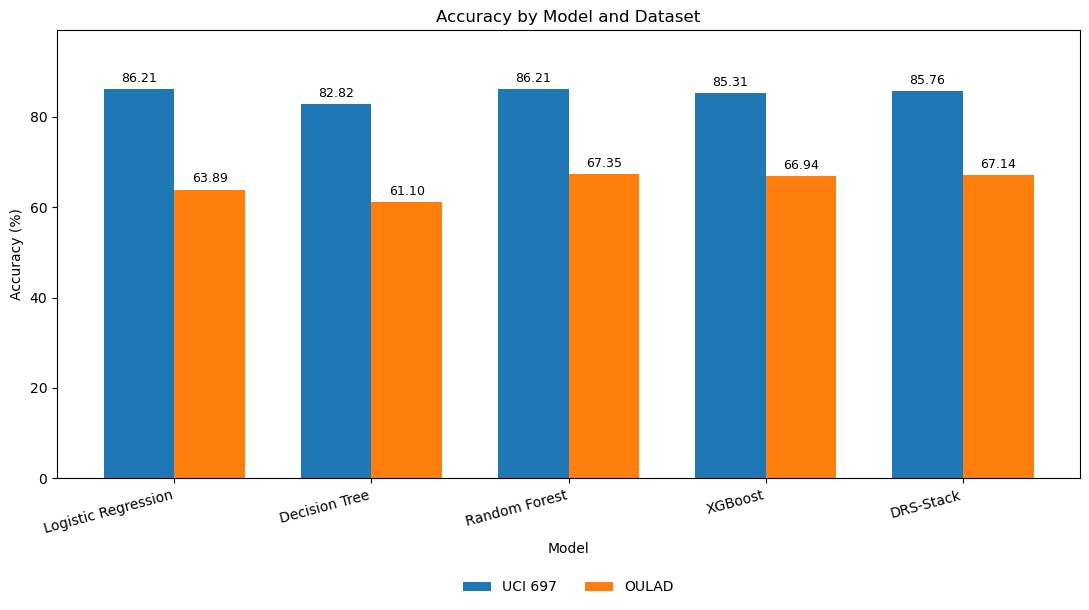

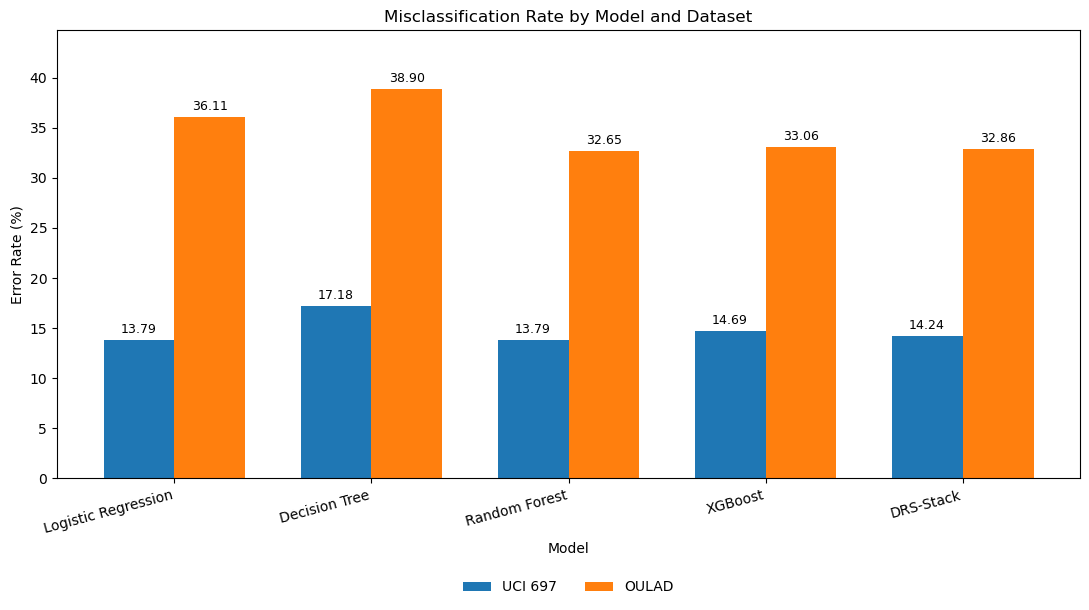

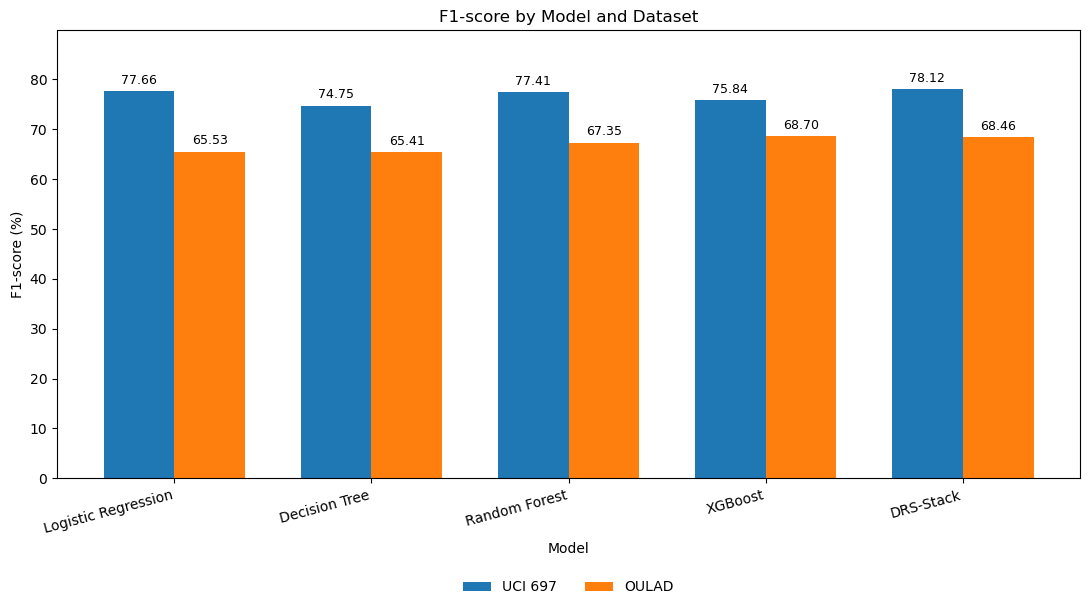

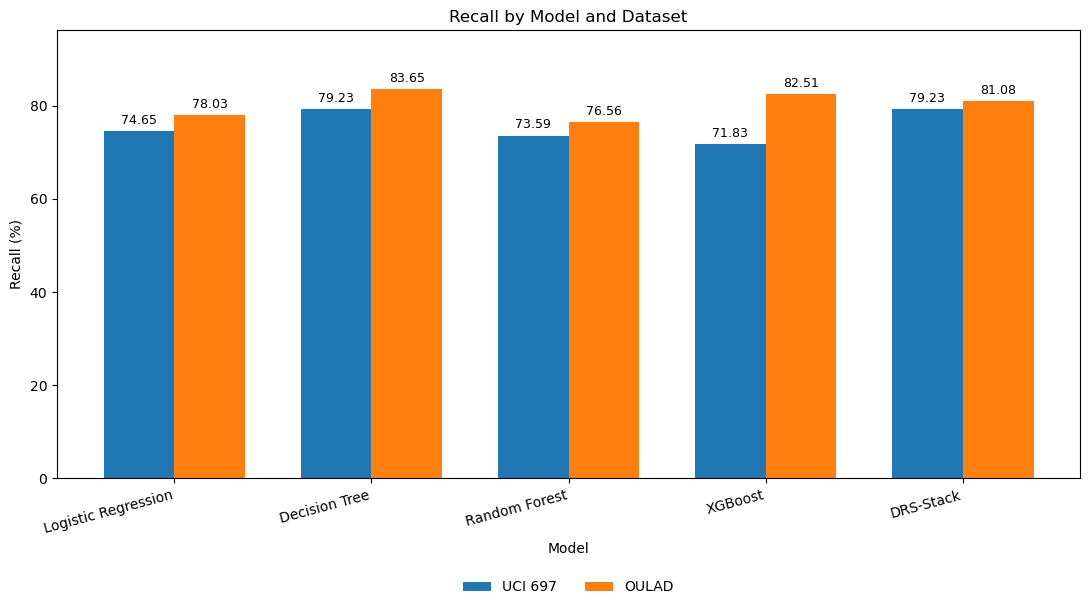

In [29]:
def metric_table(oulad_df, uci_df, metric):
    models = MODEL_NAMES + ["DRS-Stack"]

    rows = []

    for model in models:
        oulad_value = (
            oulad_df.loc[
                oulad_df["Model"] == model,
                metric
            ].iloc[0]
        )

        uci_value = (
            uci_df.loc[
                uci_df["Model"] == model,
                metric
            ].iloc[0]
        )

        rows.append({
            "Model": model,
            "OULAD": oulad_value,
            "UCI 697": uci_value
        })

    return pd.DataFrame(rows)


def plot_comparison(table, title, ylabel, filename):
    plot_data = table.copy()

    x = np.arange(len(plot_data))
    width = 0.36

    fig, ax = plt.subplots(figsize=(11, 6))

    bars_uci = ax.bar(
        x - width / 2,
        plot_data["UCI 697"],
        width,
        label="UCI 697"
    )

    bars_oulad = ax.bar(
        x + width / 2,
        plot_data["OULAD"],
        width,
        label="OULAD"
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Model")
    ax.set_xticks(x)
    ax.set_xticklabels(
        plot_data["Model"],
        rotation=15,
        ha="right"
    )

    # Hiển thị số liệu trực tiếp trên từng cột.
    ax.bar_label(
        bars_uci,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

    ax.bar_label(
        bars_oulad,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

    max_value = max(
        plot_data["UCI 697"].max(),
        plot_data["OULAD"].max()
    )

    ax.set_ylim(
        0,
        max_value * 1.15
    )

    # Chú thích đặt dưới biểu đồ.
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=2,
        frameon=False
    )

    fig.subplots_adjust(bottom=0.30)
    fig.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


accuracy_table = metric_table(
    oulad_results,
    uci_results,
    "Accuracy"
)

accuracy_table[["OULAD", "UCI 697"]] *= 100

error_table = metric_table(
    oulad_results,
    uci_results,
    "Error Rate"
)

error_table[["OULAD", "UCI 697"]] *= 100

f1_table = metric_table(
    oulad_results,
    uci_results,
    "F1"
)

f1_table[["OULAD", "UCI 697"]] *= 100

recall_table = metric_table(
    oulad_results,
    uci_results,
    "Recall"
)

recall_table[["OULAD", "UCI 697"]] *= 100

plot_comparison(
    accuracy_table,
    "Accuracy by Model and Dataset",
    "Accuracy (%)",
    "accuracy_comparison.png"
)

plot_comparison(
    error_table,
    "Misclassification Rate by Model and Dataset",
    "Error Rate (%)",
    "error_rate_comparison.png"
)

plot_comparison(
    f1_table,
    "F1-score by Model and Dataset",
    "F1-score (%)",
    "f1_comparison.png"
)

plot_comparison(
    recall_table,
    "Recall by Model and Dataset",
    "Recall (%)",
    "recall_comparison.png"
)

In [30]:
def mcnemar_exact_test(y_true, pred_a, pred_b):
    # b: A sai, B đúng
    b = np.sum((pred_a != y_true) & (pred_b == y_true))

    # c: A đúng, B sai
    c = np.sum((pred_a == y_true) & (pred_b != y_true))

    if b + c == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            min(b, c),
            n=b + c,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    return {
        "A_wrong_B_right": int(b),
        "A_right_B_wrong": int(c),
        "p_value": float(p_value)
    }


def compare_drs_with_best_baseline(
    result_df,
    y_true,
    baseline_probabilities,
    drs_probability
):
    baseline_rows = result_df[
        result_df["Model"].isin(MODEL_NAMES)
    ].copy()

    best_row = baseline_rows.sort_values(
        "Error Rate"
    ).iloc[0]

    best_name = best_row["Model"]

    best_pred = (
        baseline_probabilities[best_name]
        >= best_row["Threshold"]
    ).astype(int)

    drs_row = result_df[
        result_df["Model"] == "DRS-Stack"
    ].iloc[0]

    drs_pred = (
        drs_probability
        >= drs_row["Threshold"]
    ).astype(int)

    test_result = mcnemar_exact_test(
        y_true,
        best_pred,
        drs_pred
    )

    print("Best baseline:", best_name)
    print(
        "Baseline Error Rate:",
        round(best_row["Error Rate"] * 100, 3),
        "%"
    )
    print(
        "DRS-Stack Error Rate:",
        round(drs_row["Error Rate"] * 100, 3),
        "%"
    )
    print(
        "Difference (DRS - baseline):",
        round(
            (
                drs_row["Error Rate"]
                - best_row["Error Rate"]
            ) * 100,
            3
        ),
        "điểm %"
    )
    print("McNemar exact p-value:", round(test_result["p_value"], 6))

    return test_result


print("OULAD")
oulad_mcnemar = compare_drs_with_best_baseline(
    oulad_results,
    y_test_oulad,
    oulad_test_prob,
    oulad_drs_test_prob
)

print()
print("UCI 697")
uci_mcnemar = compare_drs_with_best_baseline(
    uci_results,
    y_uci_test,
    uci_test_prob,
    uci_drs_test_prob
)

OULAD
Best baseline: Random Forest
Baseline Error Rate: 32.646 %
DRS-Stack Error Rate: 32.861 %
Difference (DRS - baseline): 0.215 điểm %
McNemar exact p-value: 0.596692

UCI 697
Best baseline: Logistic Regression
Baseline Error Rate: 13.785 %
DRS-Stack Error Rate: 14.237 %
Difference (DRS - baseline): 0.452 điểm %
McNemar exact p-value: 0.607591


In [31]:
META_FEATURE_NAMES = [
    "P_LR",
    "P_DT",
    "P_RF",
    "P_XGB",
    "Risk_Current",
    "Risk_Mean",
    "Risk_Max",
    "Risk_Change",
    "Risk_Slope",
    "State_Changes",
    "Cluster_Distance"
]


def print_learned_equation(model, dataset_name):
    logistic = model["model"]

    coef = logistic.coef_[0]
    intercept = logistic.intercept_[0]

    print(dataset_name)
    print("P_DRS = sigmoid(")
    print(f"  {intercept:.4f}", end="")

    for name, value in zip(META_FEATURE_NAMES, coef):
        sign = "+" if value >= 0 else "-"
        print(
            f" {sign} {abs(value):.4f}*{name}",
            end=""
        )

    print(" )")

    importance = pd.DataFrame({
        "Feature": META_FEATURE_NAMES,
        "Coefficient": coef,
        "Abs_Coefficient": np.abs(coef)
    })

    return importance.sort_values(
        "Abs_Coefficient",
        ascending=False
    )


oulad_meta_importance = print_learned_equation(
    oulad_drs_model,
    "OULAD"
)

print()
uci_meta_importance = print_learned_equation(
    uci_drs_model,
    "UCI 697"
)

display(oulad_meta_importance)
display(uci_meta_importance)

OULAD
P_DRS = sigmoid(
  -0.0271 + 0.0653*P_LR + 0.0828*P_DT + 0.3191*P_RF + 0.7531*P_XGB - 0.3585*Risk_Current + 0.0914*Risk_Mean + 0.1970*Risk_Max + 0.0331*Risk_Change + 0.1477*Risk_Slope - 0.0455*State_Changes - 0.0129*Cluster_Distance )

UCI 697
P_DRS = sigmoid(
  -0.3571 + 1.0055*P_LR - 0.1117*P_DT + 0.6681*P_RF + 0.4024*P_XGB - 0.0133*Risk_Current - 0.0389*Risk_Mean + 0.1013*Risk_Max + 0.0293*Risk_Change + 0.0293*Risk_Slope - 0.1240*State_Changes - 0.0421*Cluster_Distance )


,Feature,Coefficient,Abs_Coefficient
3,P_XGB,0.753099,0.753099
4,Risk_Current,-0.358520,0.358520
2,P_RF,0.319117,0.319117
6,Risk_Max,0.196976,0.196976
8,Risk_Slope,0.147682,0.147682
5,Risk_Mean,0.091388,0.091388
1,P_DT,0.082753,0.082753
0,P_LR,0.065281,0.065281
9,State_Changes,-0.045460,0.045460
7,Risk_Change,0.033096,0.033096


,Feature,Coefficient,Abs_Coefficient
0,P_LR,1.005546,1.005546
2,P_RF,0.668098,0.668098
3,P_XGB,0.402423,0.402423
9,State_Changes,-0.123980,0.123980
1,P_DT,-0.111694,0.111694
6,Risk_Max,0.101284,0.101284
10,Cluster_Distance,-0.042114,0.042114
5,Risk_Mean,-0.038948,0.038948
8,Risk_Slope,0.029264,0.029264
7,Risk_Change,0.029264,0.029264


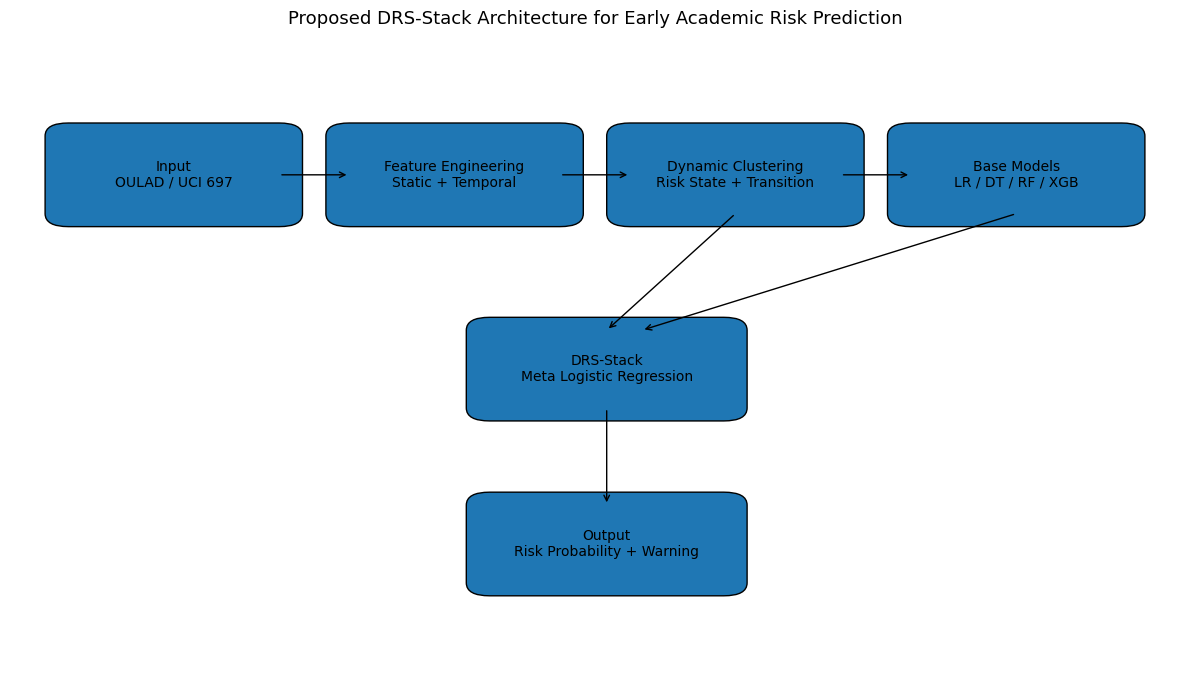

In [32]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

blocks = [
    (0.05, 0.72, 0.18, 0.12, "Input\nOULAD / UCI 697"),
    (0.29, 0.72, 0.18, 0.12, "Feature Engineering\nStatic + Temporal"),
    (0.53, 0.72, 0.18, 0.12, "Dynamic Clustering\nRisk State + Transition"),
    (0.77, 0.72, 0.18, 0.12, "Base Models\nLR / DT / RF / XGB"),
    (0.41, 0.42, 0.20, 0.12, "DRS-Stack\nMeta Logistic Regression"),
    (0.41, 0.15, 0.20, 0.12, "Output\nRisk Probability + Warning")
]

for x, y, w, h, text in blocks:
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02"
    )

    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=10
    )

# Luồng trên
for start_x, end_x in [
    (0.23, 0.29),
    (0.47, 0.53),
    (0.71, 0.77)
]:
    ax.annotate(
        "",
        xy=(end_x, 0.78),
        xytext=(start_x, 0.78),
        arrowprops=dict(arrowstyle="->")
    )

# Dynamic clustering + base model -> meta
ax.annotate(
    "",
    xy=(0.51, 0.54),
    xytext=(0.62, 0.72),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "",
    xy=(0.54, 0.54),
    xytext=(0.86, 0.72),
    arrowprops=dict(arrowstyle="->")
)

# Meta -> output
ax.annotate(
    "",
    xy=(0.51, 0.27),
    xytext=(0.51, 0.42),
    arrowprops=dict(arrowstyle="->")
)

ax.set_title(
    "Proposed DRS-Stack Architecture for Early Academic Risk Prediction",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "drs_stack_architecture.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
def build_final_comparison(oulad_df, uci_df):
    rows = []

    for model in MODEL_NAMES + ["DRS-Stack"]:
        oulad_row = oulad_df[
            oulad_df["Model"] == model
        ].iloc[0]

        uci_row = uci_df[
            uci_df["Model"] == model
        ].iloc[0]

        rows.append({
            "Model": model,
            "OULAD Accuracy": oulad_row["Accuracy"],
            "OULAD Error": oulad_row["Error Rate"],
            "OULAD Recall": oulad_row["Recall"],
            "OULAD F1": oulad_row["F1"],
            "OULAD AUC": oulad_row["ROC-AUC"],
            "UCI Accuracy": uci_row["Accuracy"],
            "UCI Error": uci_row["Error Rate"],
            "UCI Recall": uci_row["Recall"],
            "UCI F1": uci_row["F1"],
            "UCI AUC": uci_row["ROC-AUC"]
        })

    return pd.DataFrame(rows)


final_comparison = build_final_comparison(
    oulad_results,
    uci_results
)

final_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "week2_model_comparison.csv"
    ),
    index=False
)

oulad_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "oulad_results.csv"
    ),
    index=False
)

uci_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "uci697_results.csv"
    ),
    index=False
)

oulad_ablation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "oulad_ablation.csv"
    ),
    index=False
)

uci_ablation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "uci697_ablation.csv"
    ),
    index=False
)

print("Đã lưu kết quả vào:", OUTPUT_DIR)
display(final_comparison)

Đã lưu kết quả vào: week2_outputs


,Model,OULAD Accuracy,OULAD Error,OULAD Recall,OULAD F1,OULAD AUC,UCI Accuracy,UCI Error,UCI Recall,UCI F1,UCI AUC
0,Logistic Regression,0.638939,0.361061,0.780269,0.655255,0.730546,0.862147,0.137853,0.746479,0.776557,0.908984
1,Decision Tree,0.610972,0.389028,0.836527,0.654128,0.734564,0.828249,0.171751,0.792254,0.747508,0.876892
2,Random Forest,0.673539,0.326461,0.765593,0.673480,0.765079,0.862147,0.137853,0.735915,0.774074,0.903131
3,XGBoost,0.669416,0.330584,0.825112,0.687033,0.771867,0.853107,0.146893,0.718310,0.758364,0.905990
4,DRS-Stack,0.671388,0.328612,0.810844,0.684564,0.770873,0.857627,0.142373,0.792254,0.781250,0.910689


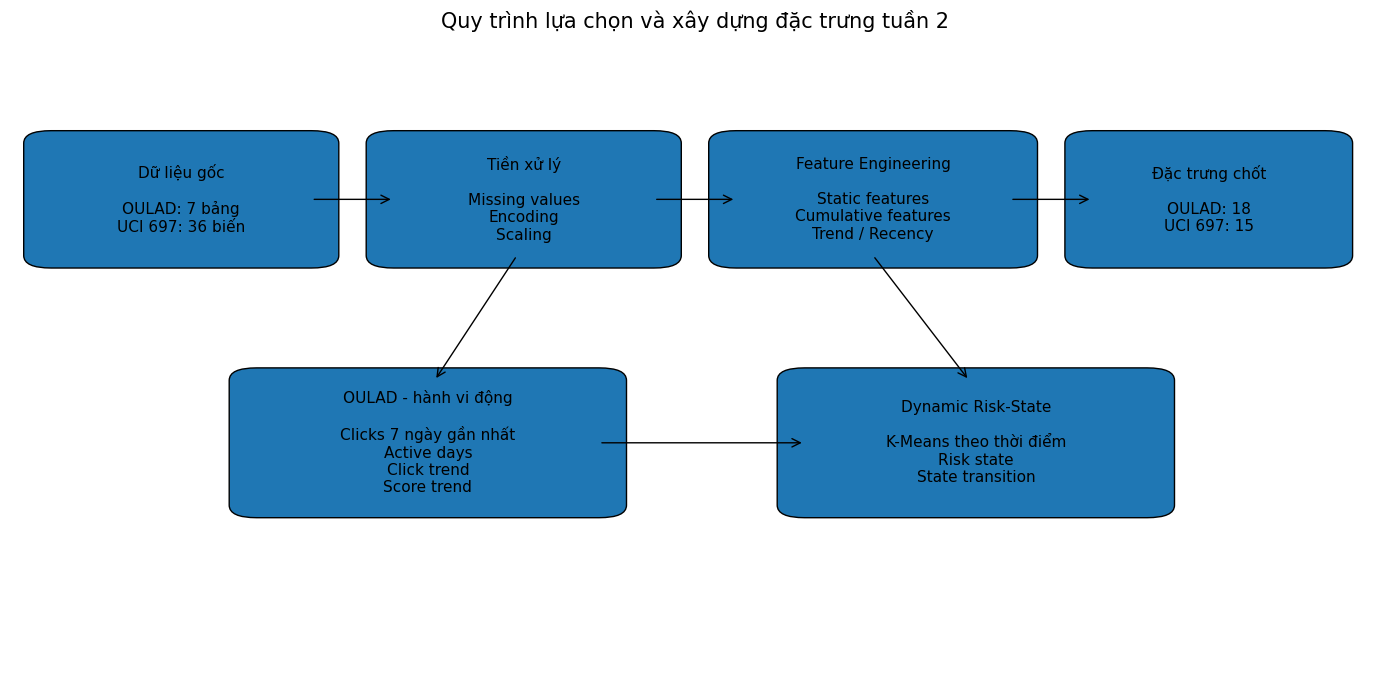

In [34]:
# ============================================================
# T2-1 - FEATURE ENGINEERING FLOW
# ============================================================

import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

os.makedirs(OUTPUT_DIR, exist_ok=True)

fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


def draw_box(
    x,
    y,
    w,
    h,
    text
):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02"
    )

    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=11
    )


def draw_arrow(
    x1,
    y1,
    x2,
    y2
):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=15
    )

    ax.add_patch(arrow)


# Hàng trên
draw_box(
    0.03,
    0.68,
    0.19,
    0.18,
    "Dữ liệu gốc\n\n"
    "OULAD: 7 bảng\n"
    "UCI 697: 36 biến"
)

draw_box(
    0.28,
    0.68,
    0.19,
    0.18,
    "Tiền xử lý\n\n"
    "Missing values\n"
    "Encoding\n"
    "Scaling"
)

draw_box(
    0.53,
    0.68,
    0.20,
    0.18,
    "Feature Engineering\n\n"
    "Static features\n"
    "Cumulative features\n"
    "Trend / Recency"
)

draw_box(
    0.79,
    0.68,
    0.17,
    0.18,
    "Đặc trưng chốt\n\n"
    "OULAD: 18\n"
    "UCI 697: 15"
)


# Hàng dưới
draw_box(
    0.18,
    0.28,
    0.25,
    0.20,
    "OULAD - hành vi động\n\n"
    "Clicks 7 ngày gần nhất\n"
    "Active days\n"
    "Click trend\n"
    "Score trend"
)

draw_box(
    0.58,
    0.28,
    0.25,
    0.20,
    "Dynamic Risk-State\n\n"
    "K-Means theo thời điểm\n"
    "Risk state\n"
    "State transition"
)


# Mũi tên
draw_arrow(
    0.22,
    0.77,
    0.28,
    0.77
)

draw_arrow(
    0.47,
    0.77,
    0.53,
    0.77
)

draw_arrow(
    0.73,
    0.77,
    0.79,
    0.77
)

draw_arrow(
    0.37,
    0.68,
    0.31,
    0.48
)

draw_arrow(
    0.63,
    0.68,
    0.70,
    0.48
)

draw_arrow(
    0.43,
    0.38,
    0.58,
    0.38
)


ax.set_title(
    "Quy trình lựa chọn và xây dựng đặc trưng tuần 2",
    fontsize=15,
    pad=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "T2_1_feature_engineering.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

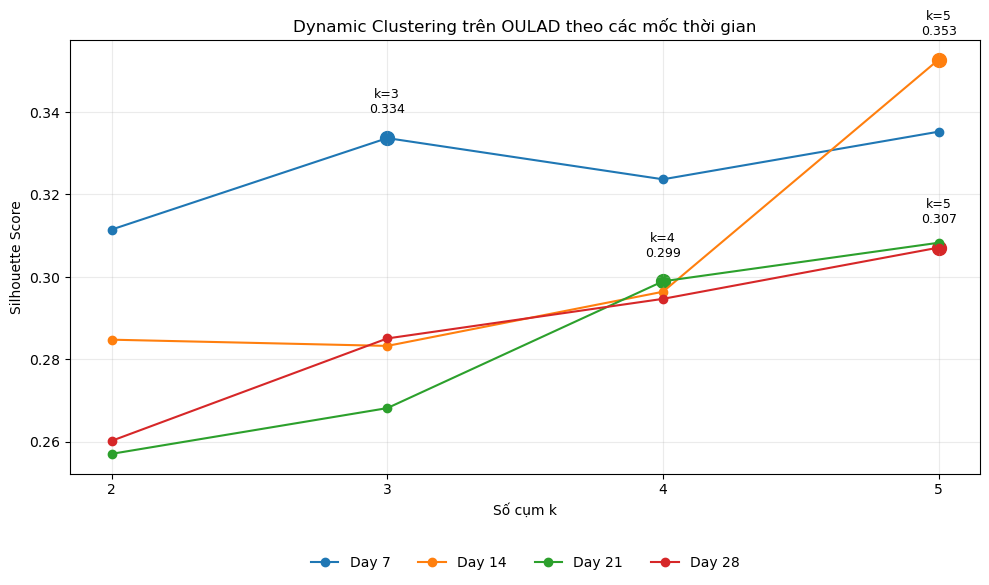

In [35]:
# ============================================================
# T2-2 - DYNAMIC CLUSTERING DIAGNOSTICS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

plt.figure(
    figsize=(10, 6)
)

for time in TIME_POINTS:

    info = oulad_cluster_diagnostics[
        time
    ]

    scores = info[
        "silhouette"
    ]

    k_values = sorted(
        scores.keys()
    )

    values = [
        scores[k]
        for k in k_values
    ]

    plt.plot(
        k_values,
        values,
        marker="o",
        label=f"Day {time}"
    )

    best_k = info[
        "best_k"
    ]

    best_score = scores[
        best_k
    ]

    # Đánh dấu điểm k được chọn
    plt.scatter(
        best_k,
        best_score,
        s=100
    )

    plt.text(
        best_k,
        best_score + 0.006,
        f"k={best_k}\n{best_score:.3f}",
        ha="center",
        fontsize=9
    )


plt.xlabel(
    "Số cụm k"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Dynamic Clustering trên OULAD theo các mốc thời gian"
)

plt.xticks(
    [2, 3, 4, 5]
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=4,
    frameon=False
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "T2_2_dynamic_clustering.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# ============================================================
# BẢNG RISK MAP CỦA CÁC CLUSTER
# ============================================================

risk_rows = []

for time in TIME_POINTS:

    info = oulad_cluster_diagnostics[
        time
    ]

    risk_map = info[
        "risk_map"
    ]

    for cluster, risk in risk_map.items():

        risk_rows.append({
            "Time": f"Day {time}",
            "Cluster": cluster,
            "Risk Rate": round(
                risk,
                4
            )
        })


risk_map_table = pd.DataFrame(
    risk_rows
)

risk_map_table

,Time,Cluster,Risk Rate
0,Day 7,0,0.3099
1,Day 7,1,0.5139
2,Day 7,2,0.6428
3,Day 14,0,0.6637
4,Day 14,1,0.2591
5,Day 14,2,0.4376
6,Day 14,3,0.6042
7,Day 14,4,0.3347
8,Day 21,0,0.7169
9,Day 21,1,0.2518


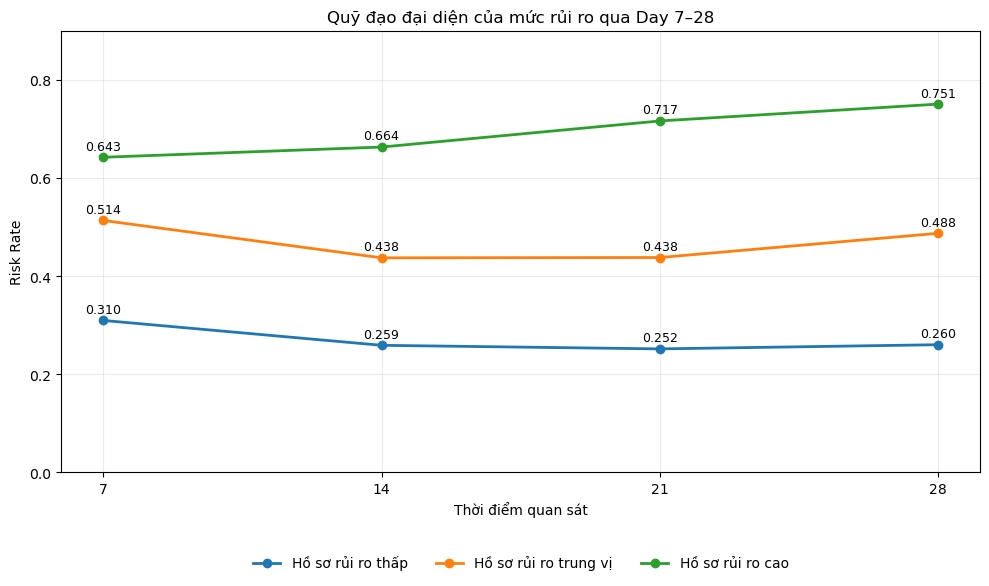

In [37]:
# ============================================================
# T2-3 - REPRESENTATIVE DYNAMIC RISK TRAJECTORY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

low_risk = []
median_risk = []
high_risk = []


for time in TIME_POINTS:

    risk_map = (
        oulad_cluster_diagnostics[
            time
        ]["risk_map"]
    )

    risks = sorted(
        risk_map.values()
    )

    low_risk.append(
        min(risks)
    )

    median_risk.append(
        float(
            np.median(
                risks
            )
        )
    )

    high_risk.append(
        max(risks)
    )


plt.figure(
    figsize=(10, 6)
)


# Low
plt.plot(
    TIME_POINTS,
    low_risk,
    marker="o",
    linewidth=2,
    label="Hồ sơ rủi ro thấp"
)


# Medium
plt.plot(
    TIME_POINTS,
    median_risk,
    marker="o",
    linewidth=2,
    label="Hồ sơ rủi ro trung vị"
)


# High
plt.plot(
    TIME_POINTS,
    high_risk,
    marker="o",
    linewidth=2,
    label="Hồ sơ rủi ro cao"
)


# =========================
# Ghi số trên điểm
# =========================

for values in [
    low_risk,
    median_risk,
    high_risk
]:

    for x, y in zip(
        TIME_POINTS,
        values
    ):

        plt.text(
            x,
            y + 0.015,
            f"{y:.3f}",
            ha="center",
            fontsize=9
        )


plt.xticks(
    TIME_POINTS
)

plt.xlabel(
    "Thời điểm quan sát"
)

plt.ylabel(
    "Risk Rate"
)

plt.title(
    "Quỹ đạo đại diện của mức rủi ro qua Day 7–28"
)

plt.ylim(
    0,
    min(
        1,
        max(high_risk) + 0.15
    )
)

plt.grid(
    alpha=0.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "T2_3_risk_trajectory.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

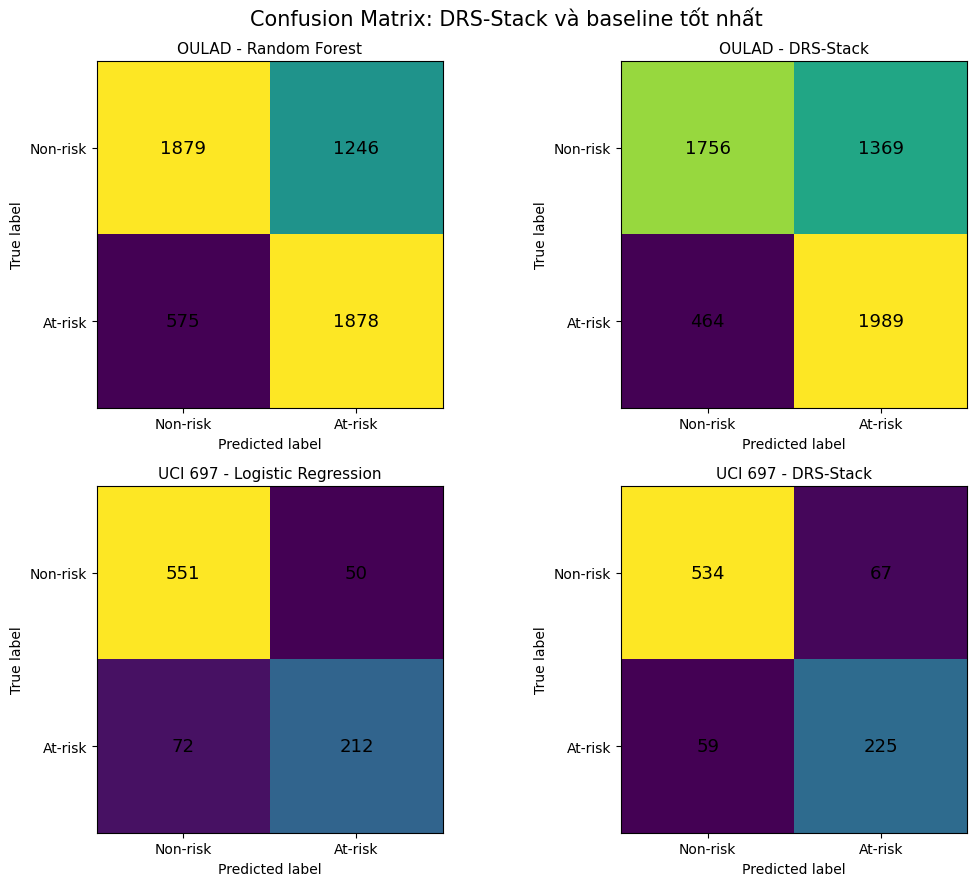

In [38]:
# ============================================================
# T2-8 - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os


def get_best_baseline(
    result_df
):

    baseline_df = result_df[
        result_df[
            "Model"
        ].isin(
            MODEL_NAMES
        )
    ].copy()

    best_row = (
        baseline_df
        .sort_values(
            "Error Rate"
        )
        .iloc[0]
    )

    return best_row


def draw_cm(
    ax,
    matrix,
    title
):

    image = ax.imshow(
        matrix
    )

    ax.set_title(
        title,
        fontsize=11
    )

    ax.set_xlabel(
        "Predicted label"
    )

    ax.set_ylabel(
        "True label"
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_xticklabels(
        [
            "Non-risk",
            "At-risk"
        ]
    )

    ax.set_yticklabels(
        [
            "Non-risk",
            "At-risk"
        ]
    )

    # Ghi số trong từng ô
    for i in range(2):

        for j in range(2):

            ax.text(
                j,
                i,
                str(
                    matrix[i, j]
                ),
                ha="center",
                va="center",
                fontsize=13
            )


# ============================================================
# OULAD
# ============================================================

best_oulad = get_best_baseline(
    oulad_results
)

best_oulad_name = (
    best_oulad[
        "Model"
    ]
)

best_oulad_threshold = (
    best_oulad[
        "Threshold"
    ]
)


oulad_baseline_pred = (
    oulad_test_prob[
        best_oulad_name
    ]
    >=
    best_oulad_threshold
).astype(int)


oulad_drs_pred = (
    oulad_drs_test_prob
    >=
    oulad_drs_threshold
).astype(int)


cm_oulad_base = (
    confusion_matrix(
        y_test_oulad,
        oulad_baseline_pred
    )
)

cm_oulad_drs = (
    confusion_matrix(
        y_test_oulad,
        oulad_drs_pred
    )
)


# ============================================================
# UCI 697
# ============================================================

best_uci = get_best_baseline(
    uci_results
)

best_uci_name = (
    best_uci[
        "Model"
    ]
)

best_uci_threshold = (
    best_uci[
        "Threshold"
    ]
)


uci_baseline_pred = (
    uci_test_prob[
        best_uci_name
    ]
    >=
    best_uci_threshold
).astype(int)


uci_drs_pred = (
    uci_drs_test_prob
    >=
    uci_drs_threshold
).astype(int)


cm_uci_base = confusion_matrix(
    y_uci_test,
    uci_baseline_pred
)

cm_uci_drs = confusion_matrix(
    y_uci_test,
    uci_drs_pred
)


# ============================================================
# VẼ HÌNH
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 9)
)


draw_cm(
    axes[0, 0],
    cm_oulad_base,
    "OULAD - "
    +
    best_oulad_name
)

draw_cm(
    axes[0, 1],
    cm_oulad_drs,
    "OULAD - DRS-Stack"
)

draw_cm(
    axes[1, 0],
    cm_uci_base,
    "UCI 697 - "
    +
    best_uci_name
)

draw_cm(
    axes[1, 1],
    cm_uci_drs,
    "UCI 697 - DRS-Stack"
)


fig.suptitle(
    "Confusion Matrix: DRS-Stack và baseline tốt nhất",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "T2_8_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# ============================================================
# KIỂM TRA CÁC HÌNH ĐÃ TẠO
# ============================================================

import os

images = [
    "T2_1_feature_engineering.png",
    "T2_2_dynamic_clustering.png",
    "T2_3_risk_trajectory.png",

    "drs_stack_architecture.png",

    "accuracy_comparison.png",
    "error_rate_comparison.png",
    "f1_comparison.png",
    "recall_comparison.png",

    "T2_8_confusion_matrix.png"
]


print(
    "DANH SÁCH HÌNH TUẦN 2"
)

print(
    "=" * 60
)


for file in images:

    path = os.path.join(
        OUTPUT_DIR,
        file
    )

    if os.path.exists(
        path
    ):

        print(
            "OK  ",
            file
        )

    else:

        print(
            "THIẾU",
            file
        )

DANH SÁCH HÌNH TUẦN 2
OK   T2_1_feature_engineering.png
OK   T2_2_dynamic_clustering.png
OK   T2_3_risk_trajectory.png
OK   drs_stack_architecture.png
OK   accuracy_comparison.png
OK   error_rate_comparison.png
OK   f1_comparison.png
OK   recall_comparison.png
OK   T2_8_confusion_matrix.png
